In [70]:
import pandas as pd
import pandas.io.sql as sqlio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import sqlalchemy
import psycopg2 as ps
from sqlalchemy import create_engine
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier
import lightgbm as lgb
from sklearn.naive_bayes import GaussianNB



In [50]:
from connexion import Connexion as cnn
fa = """SELECT * FROM public."Fact_Activity";"""
fo= """SELECT * FROM public."Fact_Orders";"""
da= """SELECT * FROM public."Dim_Accident";"""
dc= """SELECT * FROM public."Dim_Customer";"""
dd= """SELECT * FROM public."Dim_Date";"""
de= """SELECT * FROM public."Dim_Event";"""
dm= """SELECT * FROM public."Dim_Meteo";"""
dp= """SELECT * FROM public."Dim_Payment";"""
dpp= """SELECT * FROM public."Dim_Products";"""
du= """SELECT * FROM public."Dim_User";"""

dim_acc = cnn.connect_to_dw(da)
dim_acc = pd.DataFrame(dim_acc)
dim_cus = cnn.connect_to_dw(dc)
dim_cus = pd.DataFrame(dim_cus)
dim_date = cnn.connect_to_dw(dd)
dim_date = pd.DataFrame(dim_date)
dim_event = cnn.connect_to_dw(de)
dim_event = pd.DataFrame(dim_event)
dim_meteo = cnn.connect_to_dw(dm)
dim_meteo = pd.DataFrame(dim_meteo)
dim_payment = cnn.connect_to_dw(dp)
dim_payment = pd.DataFrame(dim_payment)
dim_product = cnn.connect_to_dw(dpp)
dim_product = pd.DataFrame(dim_product)
dim_user = cnn.connect_to_dw(du)
dim_user = pd.DataFrame(dim_user)
fact_activity = cnn.connect_to_dw(fa)
fact_activity = pd.DataFrame(fact_activity)
fact_orders = cnn.connect_to_dw(fo)
fact_orders = pd.DataFrame(fact_orders)



In [51]:
def shuufle_data(data):
    original_dtypes=data.dtypes
    dim_date_array = data.values

    # Shuffle the rows
    np.random.shuffle(dim_date_array)

    # Convert back to DataFrame
    shuffled_dim_date = pd.DataFrame(dim_date_array, columns=data.columns)
    shuffled_dim_date = shuffled_dim_date.astype(original_dtypes)

    data=shuffled_dim_date
    return data

### Identify distinct visitor segments

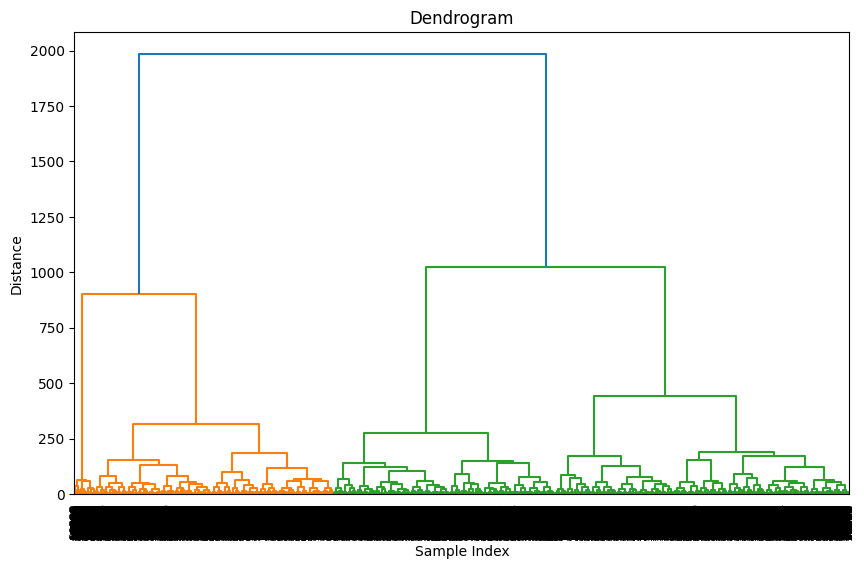

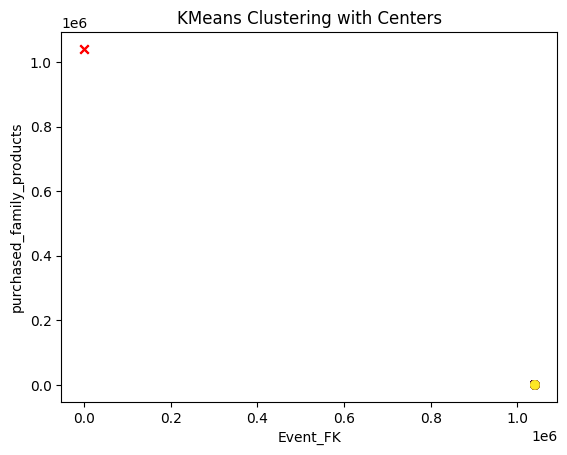

In [75]:
from scipy.cluster.hierarchy import linkage

df_segment = pd.merge(fact_activity, dim_date, left_on='Date_FK', right_on='Date_PK')
df_segment = df_segment[['Month','Products_FK', 'Event_FK']]

family_products = [1040369,1040373,1040374,1040375,1040376,1040381,1040382,1040384,1040385] 
df_segment['purchased_family_products'] = df_segment['Products_FK'].isin(family_products).astype(int)
df_segment['purchased_family_products']
# Step 2: Select relevant features for clustering
X = df_segment[['Month', 'Event_FK', 'purchased_family_products']]

# Compute the linkage matrix
Z = linkage(df_segment, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
plt.title('Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90., leaf_font_size=8.)
plt.show()

# Step 3: Perform KMeans clustering
kmeans = KMeans(n_clusters=2)  
kmeans.fit(X)

# Get the cluster labels
# Calculate the cluster centers
centers = kmeans.cluster_centers_
cluster_labels=kmeans.labels_
# Plotting the individuals
plt.scatter(X['Event_FK'], X['purchased_family_products'], c=cluster_labels, cmap='viridis')

# Plotting the centers
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x')

plt.xlabel('Event_FK')
plt.ylabel('purchased_family_products')
plt.title('KMeans Clustering with Centers')
plt.show()


The analysis uses hierarchical and KMeans clustering to identify patterns in product purchases across different events. The hierarchical clustering dendrogram reveals distinct groups based on purchase behavior and event characteristics, suggesting varying levels of similarity among data points. KMeans clustering further categorizes these into two main clusters, differentiated by event types and family product purchases, as shown in the scatter plot with clearly marked cluster centers. These findings suggest that certain events correlate more strongly with family product purchases, offering insights into consumer behavior for targeted marketing strategies. Further analysis could improve by optimizing clustering parameters and feature selection.